## Library check

In [ ]:
import numpy as np
import torch
import torchaudio
import cLogger

#Create Log
log = cLogger.Log("output/logs/", prefix="test")

print(log.log_property("torch_version", torch.__version__))
print(log.log_property("torchaudio_version", torchaudio.__version__))

if torch.cuda.is_available():
    print(log.log_property("device", "cuda"))
    print(log.log_property("GPU_count", torch.cuda.device_count()))
    print(log.log_property("GPU_device", torch.cuda.get_device_name(0)))
else:
    print(log.log_property("device", "cpu"))

torch_version: 2.5.1
torchaudio_version: 2.5.1
device: cuda
GPU_count: 1
GPU_device: NVIDIA GeForce GTX 1050


## Load Dataset

Feature batch shape: torch.Size([16, 1, 20, 922])
Labels batch shape: torch.Size([16, 3])


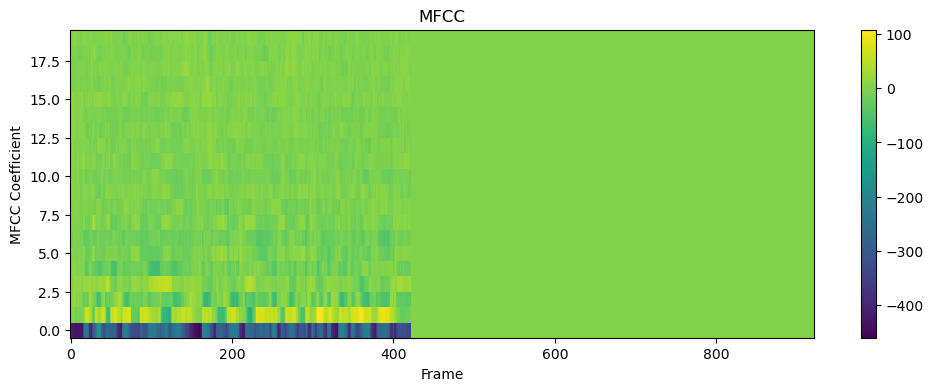

MFCC:  tensor([[[-4.1159e+02, -4.0713e+02, -4.2361e+02,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-8.8097e-01, -3.0663e+00,  1.4292e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 8.8380e+00,  1.0125e+01,  1.3301e+01,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [-9.8353e-01,  3.3963e+00, -3.7383e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-3.7215e-01,  1.4808e+00, -3.3542e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-7.3424e-01,  4.1701e+00,  3.6102e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]]])
Label: tensor([-0.6667,  0.0000,  1.0000])


In [2]:
import audiotools
import torch
import torchaudio
import cTransforms
from torch.utils.data import DataLoader

#Dataset parameters:
loader_params = {
    "batch_size": 16,
    "shuffle": True,
    "collate_function": audiotools.Batching.spectrogram_dynamic,
    "target_transform": cTransforms.NormalizeMinus(1, 7)
    }

#Spectogram parameters
spectogram_transform = torchaudio.transforms.Spectrogram(
    n_fft=1024,
    hop_length=160,
    win_length=400,
    window_fn=torch.hamming_window,
    normalized=True,
    power=2
    )

melspectogram_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=512,
    win_length=400,
    hop_length=160,
    window_fn=torch.hamming_window,
    power=2,
    n_mels=64,
    normalized=True,
    pad_mode="constant",
    mel_scale="htk"
)

mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=16000,
    n_mfcc=20,
    melkwargs={
        #"sample_rate": 16000,
        "n_fft": 512,
        "win_length": 400,
        "hop_length": 160,
        "window_fn": torch.hamming_window,
        "power": 2,
        "n_mels": 64,
        "normalized": True,
        "pad_mode": "constant",
        "mel_scale": "htk"
    }
)

log.log_properties("Data", loader_params)
log.log_property("spectogram_transform", spectogram_transform)
log.log_property("mfcc_transform", mfcc_transform)
log.save()

#Train partition
msp_vad_train = audiotools.AudioDatasetVAD(
    r"C:\Datasets\_compiled\msp-podcast-2\labels_train_VAD.csv", 
    r"C:\Datasets\_compiled\msp-podcast-2\Train",
    transform=mfcc_transform,
    target_transform=loader_params["target_transform"]
    )
train_dataloader = DataLoader(
    msp_vad_train,
    batch_size=loader_params["batch_size"],
    shuffle=loader_params["shuffle"],
    collate_fn=loader_params["collate_function"]
    )

#Development(validation) partition
msp_vad_dev = audiotools.AudioDatasetVAD(
    r"C:\Datasets\_compiled\msp-podcast-2\labels_development_VAD.csv",
    r"C:\Datasets\_compiled\msp-podcast-2\Development",
    transform=spectogram_transform,
    target_transform=loader_params["target_transform"]
    )
dev_dataloader = DataLoader(
    msp_vad_dev,
    batch_size=loader_params["batch_size"],
    shuffle=loader_params["shuffle"],
    collate_fn=loader_params["collate_function"]
    )

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

sample = train_features[0]
label = train_labels[0]

spectogram_2_db = torchaudio.transforms.AmplitudeToDB(
    stype='power',
    #top_db=80
    )
#audiotools.Plot.spectrogram(spectogram_2_db(sample), ylabel="Frequency Bin", xlabel="Frame", cmap="viridis")
audiotools.Plot.mfcc(sample)
print("MFCC: ", sample)
print(f"Label: {label}")